<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/notebook/ScrapReview_bluApp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-play-scraper
!pip install textblob
!pip install seaborn

from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_theme()
plt.rcParams["figure.figsize"] = (15,10)

In [2]:
#Android App blu by BCA link from Google Play at
#https://play.google.com/store/apps/details?id=com.bcadigital.blu
#The apps ID found in the link after id=com.bcadigital.blu
#The apps name on Google Play titled: blu by BCA Digital
#Dated 2 March 2026 | Number of reviews: 113k

from google_play_scraper import app, Sort, reviews_all

blu_reviews = reviews_all(
    'com.bcadigital.blu',
    sleep_milliseconds=0,
    lang='id',
    sort=Sort.NEWEST,
)

In [3]:
#Save the blu Apps reviews into dataframe
df_bluRev = pd.DataFrame(np.array(blu_reviews),columns=['content'])
df_bluRev = df_bluRev.join(pd.DataFrame(df_bluRev.pop('content').tolist()))
df_bluRev.to_csv(r'df_bluRev.csv', index=False)
df_bluRev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,390bc946-6953-447d-9ec0-dc7b3931c77b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Semoga makin lancar aplikasi nya hueee 😭,5,0,2.9.20,2026-03-09 15:29:14,"Hai, Kak Zahra. Terima kasih atas ulasannya. S...",2026-03-09 17:09:58,2.9.20
1,b9a6c1be-3c3b-4954-b469-42f8f0633007,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ini kenap kok akun bca saya ke blokir tiba tib...,2,0,1.43.0,2026-03-09 15:25:15,"Hai, Kak Putri. Maaf atas ketidaknyamanannya. ...",2026-03-09 16:10:48,1.43.0
2,90167173-766f-4608-a9c6-0b6626c326a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap mudah,5,0,2.9.20,2026-03-09 15:08:41,"Hai, Kak Budi. Terima kasih atas ulasannya. Se...",2026-03-09 16:08:42,2.9.20
3,788b5a39-872c-40ee-b859-c8e6c789a81f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,2.9.20,2026-03-09 15:00:08,"Hai, Kak Ade. Terima kasih atas ulasannya. Sem...",2026-03-09 16:08:29,2.9.20
4,d397690b-fe12-499a-b57b-89ad6930dc82,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak ada fitur login buat pengguna yang sudah t...,3,0,None,2026-03-09 13:38:56,Hai Kak Tomi. Maaf atas ketidaknyamanannya. Un...,2026-03-09 14:00:58,None


In [4]:
print(df_bluRev.reviewCreatedVersion.unique())
print(df_bluRev.reviewCreatedVersion.nunique())

['2.9.20' '1.43.0' None '2.9.0' '2.9.10' '2.8.10' '2.7.20' '2.6.0'
 '2.7.10' '2.3.0' '2.1.10' '1.51.0' '2.8.0' '1.17.0' '2.4.0' '1.49.0'
 '2.5.0' '2.7.0' '1.57.10' '1.47.0' '1.55.0' '1.61.0' '1.59.20' '1.47.10'
 '1.29.10' '2.2.0' '1.15.0' '1.53.10' '1.37.0' '1.64.0' '1.57.20' '2.0.20'
 '1.58.0' '2.1.0' '1.67.0' '1.27.0' '2.0.30' '1.26.1' '1.31.0' '1.14.0'
 '1.50.0' '1.66.0' '2.0.0' '1.65.0' '2.0.10' '1.48.10' '1.56.0' '1.63.10'
 '1.33.0' '1.59.10' '1.42.10' '1.48.0' '1.60.0' '1.35.10' '1.62.10'
 '1.29.0' '1.63.0' '1.10.0' '1.59.0' '1.57.0' '1.43.10' '1.62.0' '1.23.0'
 '1.45.0' '1.25.0' '1.54.0' '1.53.0' '1.52.0' '1.38.0' '1.46.0' '1.52.10'
 '1.40.0' '1.30.0' '1.32.10' '1.20.0' '1.9.0' '1.36.0' '1.6.0' '1.42.0'
 '1.12.0' '1.41.0' '1.39.10' '1.39.0' '1.28.0' '1.40.10' '1.19.0' '1.18.0'
 '1.34.0' '1.22.0' '1.21.0' '1.35.0' '1.7.0' '1.28.10' '1.24.0' '1.32.0'
 '1.13.0' '1.26.0' '1.16.0' '1.24.10' '1.11.0' '1.8.0' '1.5.0' '1.3.2'
 '1.4.0' '1.2.1' '1.3.3' '1.3.0']
106


In [5]:
#We do not need data for column reviewId, userName, userImage so we will show only these column
df_bluRev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,Semoga makin lancar aplikasi nya hueee 😭,5,0,2.9.20,2026-03-09 15:29:14,"Hai, Kak Zahra. Terima kasih atas ulasannya. S...",2026-03-09 17:09:58
1,ini kenap kok akun bca saya ke blokir tiba tib...,2,0,1.43.0,2026-03-09 15:25:15,"Hai, Kak Putri. Maaf atas ketidaknyamanannya. ...",2026-03-09 16:10:48
2,mantap mudah,5,0,2.9.20,2026-03-09 15:08:41,"Hai, Kak Budi. Terima kasih atas ulasannya. Se...",2026-03-09 16:08:42
3,mantap,5,0,2.9.20,2026-03-09 15:00:08,"Hai, Kak Ade. Terima kasih atas ulasannya. Sem...",2026-03-09 16:08:29
4,gak ada fitur login buat pengguna yang sudah t...,3,0,None,2026-03-09 13:38:56,Hai Kak Tomi. Maaf atas ketidaknyamanannya. Un...,2026-03-09 14:00:58
...,...,...,...,...,...,...,...
25338,"Selamat pagi masyarakat BCA DIGITAL, hehehehe😁...",5,0,1.3.2,2021-07-02 02:59:18,"Hai, Kak Ridwan Mukti Sastama. Terima kasih at...",2021-07-04 08:24:53
25339,"Ribet ...minta diaktifkan screen lock, dah akt...",1,0,1.3.2,2021-07-02 02:53:23,"Hai, Kak Hidayat Hidayat. Terima kasih untuk f...",2021-07-04 07:59:53
25340,Video call kok ngk berhasil,5,0,1.3.2,2021-07-02 02:50:42,"Hai, Kak Roni Susanto. Terima kasih untuk feed...",2021-07-04 07:49:57
25341,Pertamax....test,3,1,None,2021-07-02 02:42:19,"Hai, Kak Zainal CorRosion. Terima kasih atas u...",2021-07-04 07:34:47


In [6]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
import regex
import nltk
import wordcloud

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.7 MB/s eta 0:00:00


In [7]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_bluRev['sentiment_polarity'] = df_bluRev['content'].apply(lambda x: TextBlob(x).polarity)
df_bluRev['sentiment_subjective'] = df_bluRev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [8]:
#df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,Semoga makin lancar aplikasi nya hueee 😭,5,0.0,0.0
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,0.0,0.0
2,mantap mudah,5,0.0,0.0
3,mantap,5,0.0,0.0
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,0.0,0.0
...,...,...,...,...
25338,"Selamat pagi masyarakat BCA DIGITAL, hehehehe😁😁😁😍😍😍",5,0.0,0.0
25339,"Ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,0.0,0.0
25340,Video call kok ngk berhasil,5,0.0,0.0
25341,Pertamax....test,3,0.0,0.0


In [9]:
#Check number of reviews scores
df_bluRev['score'].value_counts()

,count
score,
5,14194
1,5978
4,1938
3,1769
2,1464


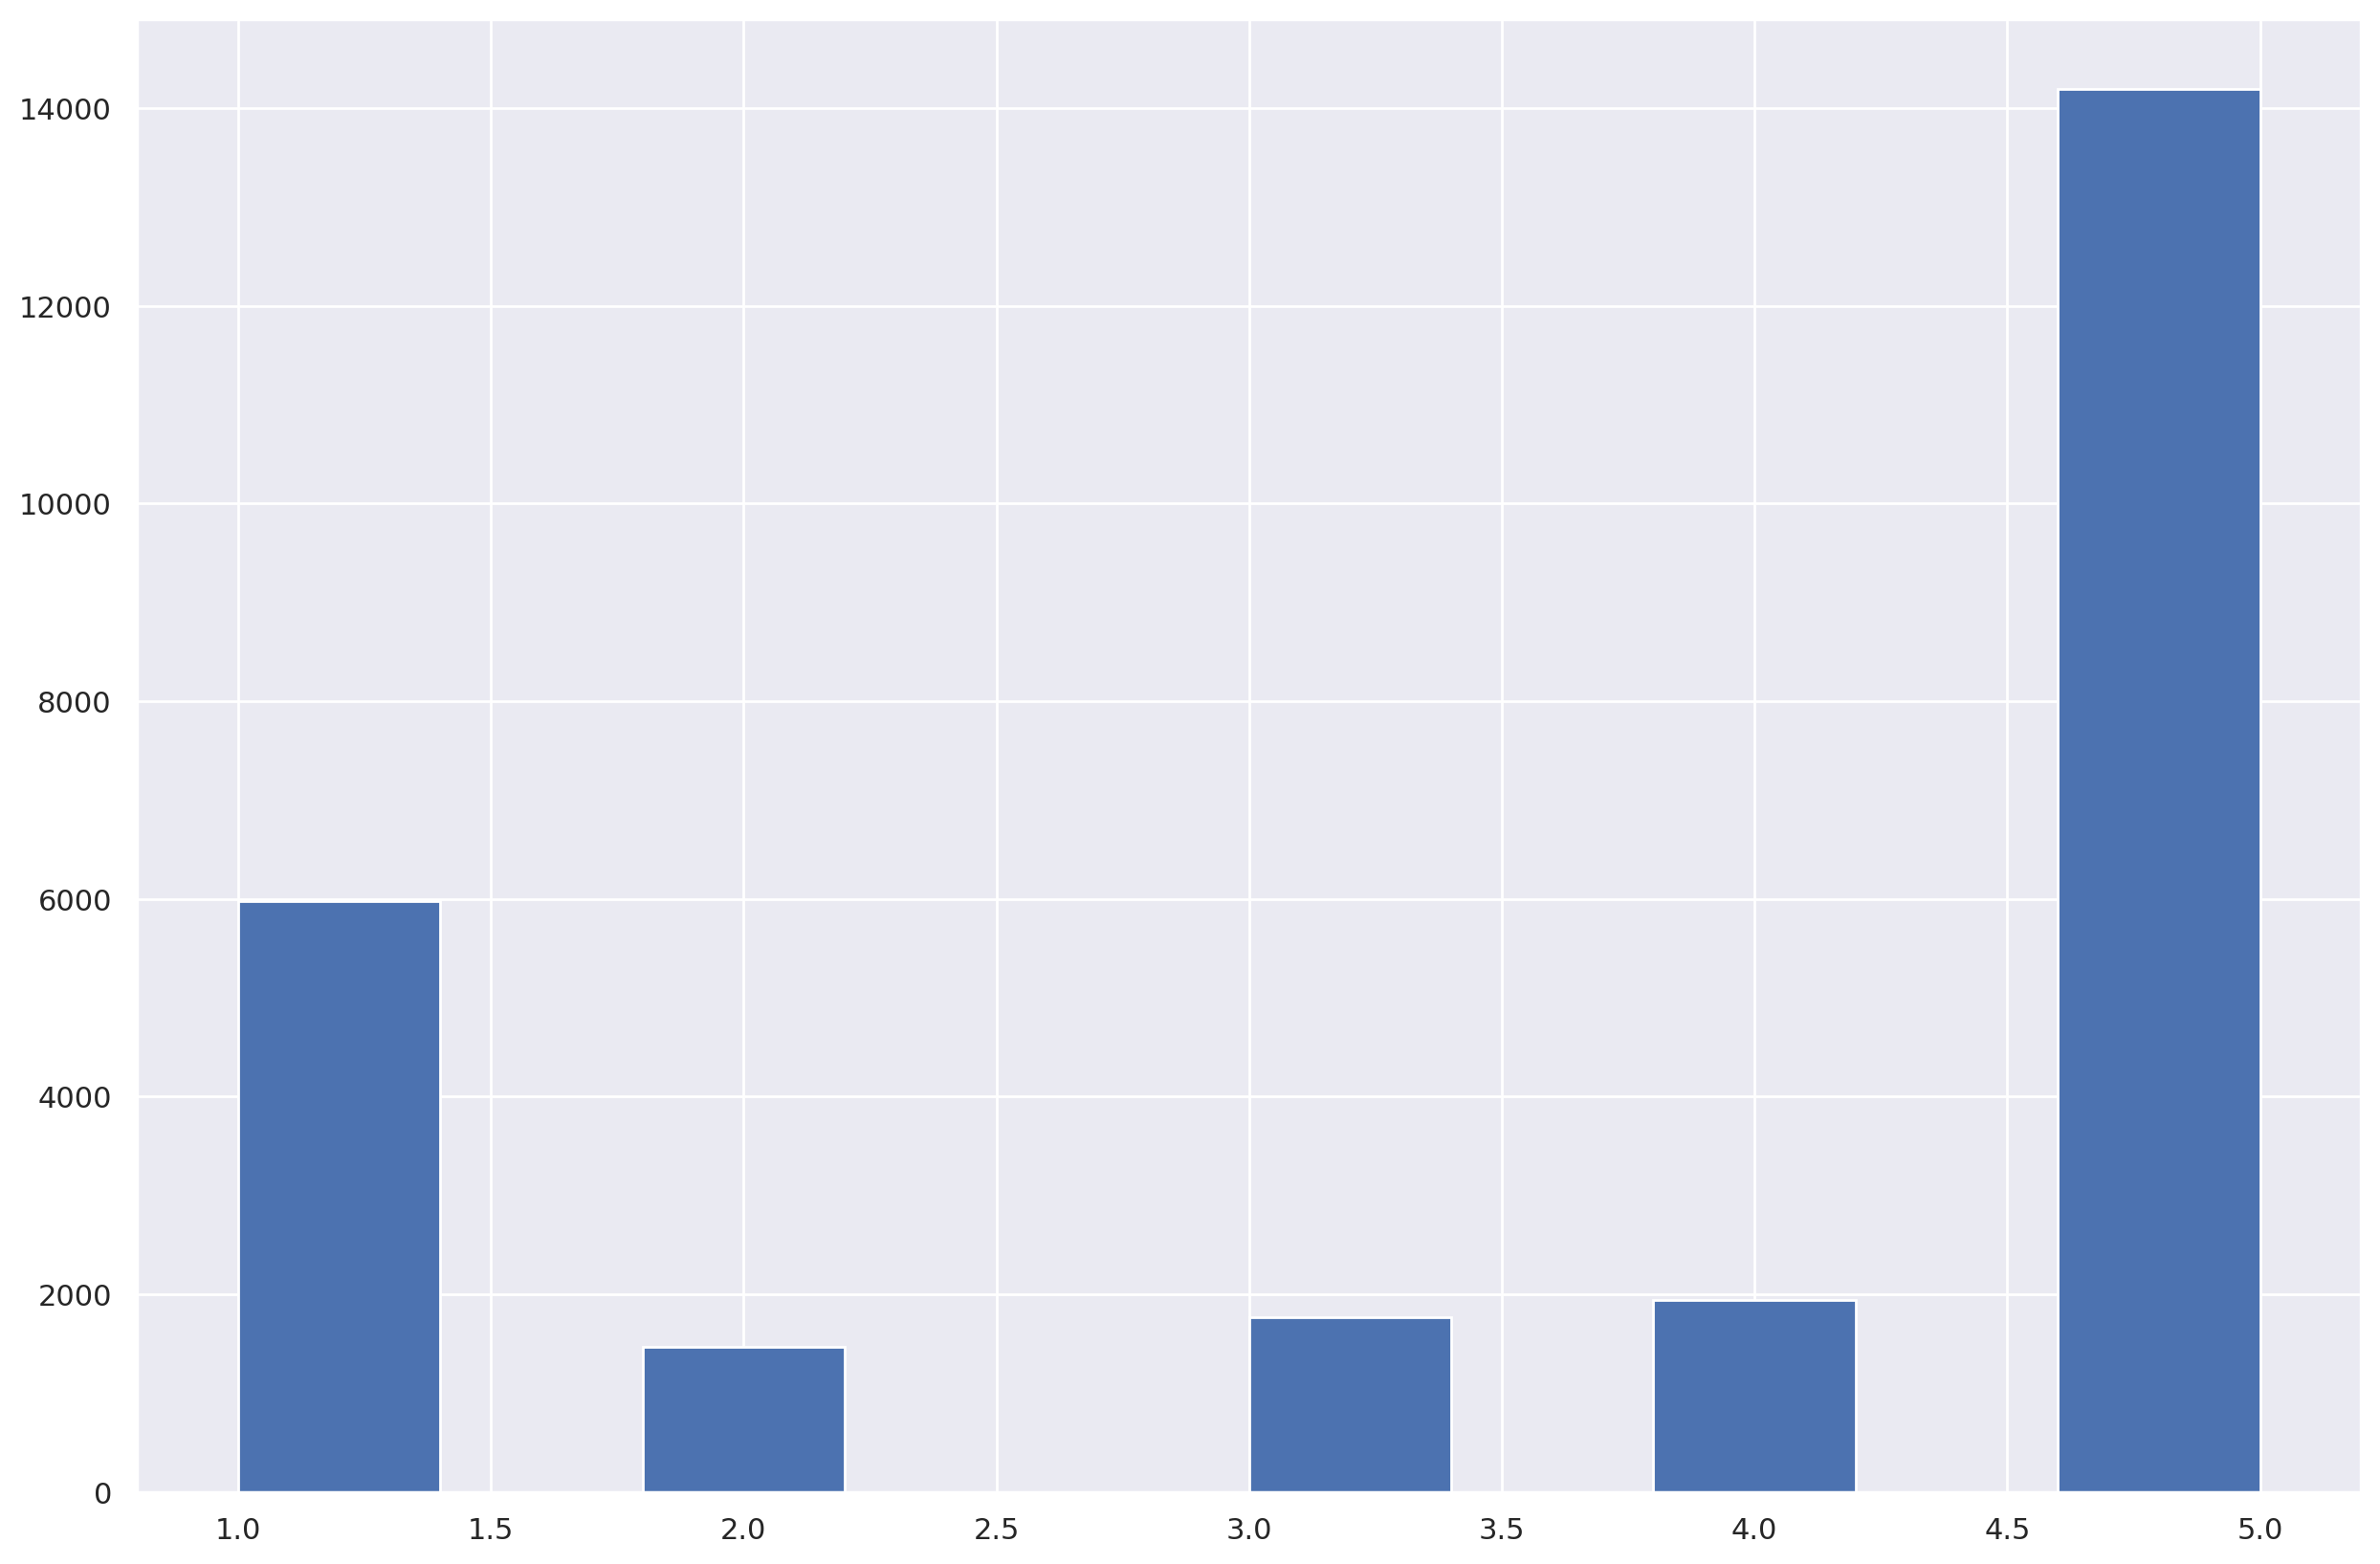

In [10]:
plt.hist(df_bluRev['score'])
plt.show()

In [11]:
#DATA PREPROCESSING

#Lower casing
#Change the reviews type to string
df_bluRev['content'] = df_bluRev['content'].astype(str)
#Before lowercasing
print(df_bluRev['content'][1])

ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka


In [12]:
#Lowercase all reviews to see the difference
df_bluRev['content']= df_bluRev['content'].apply(lambda x: x.lower())
print(df_bluRev['content'][1])

ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka


In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_bluRev['wordCount'] = [len(review.split()) for review in df_bluRev['content']]

df_bluRev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_bluRev['content']]

df_bluRev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_bluRev['content']]

In [15]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,semoga makin lancar aplikasi nya hueee 😭,5,0.0,0.0,7,0,0
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,0.0,0.0,13,0,0
2,mantap mudah,5,0.0,0.0,2,0,0
3,mantap,5,0.0,0.0,1,0,0
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,0.0,0.0,20,0,1
...,...,...,...,...,...,...,...
25338,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",5,0.0,0.0,6,0,1
25339,"ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,0.0,0.0,11,0,5
25340,video call kok ngk berhasil,5,0.0,0.0,5,0,0
25341,pertamax....test,3,0.0,0.0,1,0,4


In [16]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [17]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

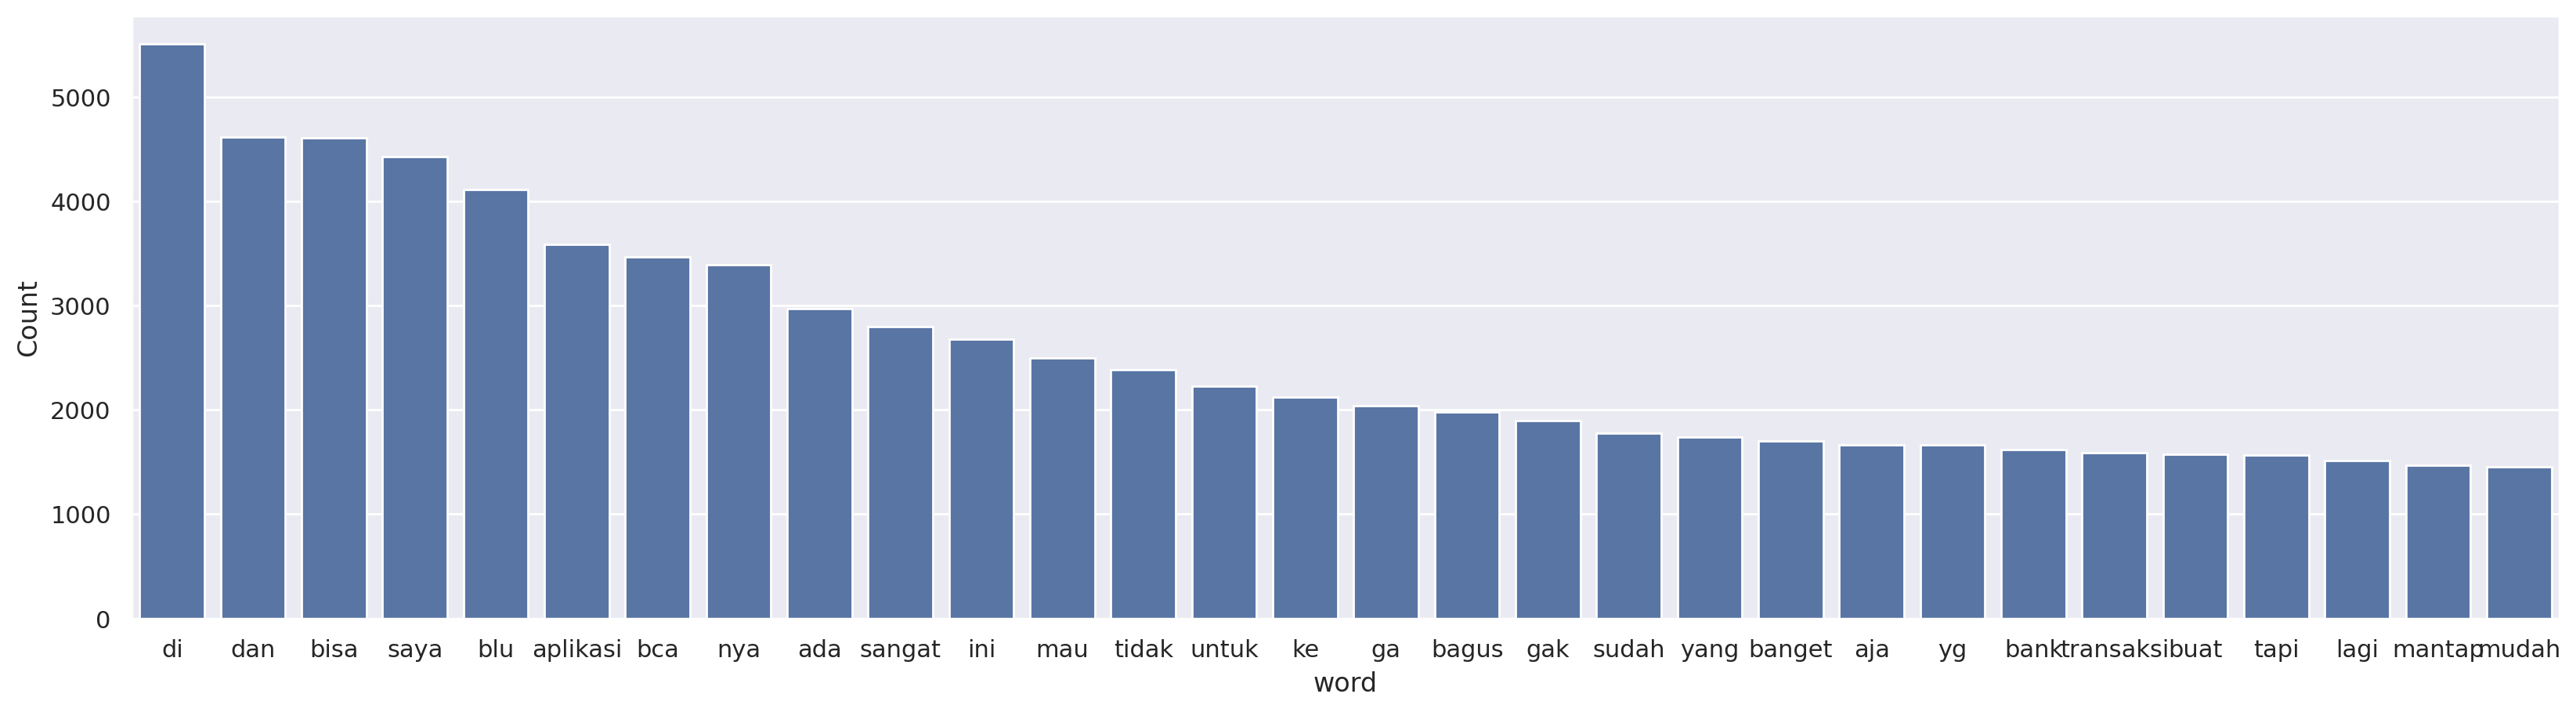

In [18]:
freq_words(df_bluRev['content'])

In [19]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_bluRev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)
    return expe.sub(r'',s)

for y in df_bluRev['content']:
    #print(str(extract_emojis(y)))
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)

True
["['😭']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍']", "['👍']", '[]', "['😁']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🥱']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🤦']", "['👍', '👍', '🥰']", '[]', '[]', '[]', '[]', '[]', '[]', "['👽']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '👍']", "['😭', '😭']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🤦']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😡']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍']", '[]', '[]',

In [20]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,semoga makin lancar aplikasi nya hueee 😭,5,0.0,0.0,7,0,0
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,0.0,0.0,13,0,0
2,mantap mudah,5,0.0,0.0,2,0,0
3,mantap,5,0.0,0.0,1,0,0
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,0.0,0.0,20,0,1
...,...,...,...,...,...,...,...
25338,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",5,0.0,0.0,6,0,1
25339,"ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,0.0,0.0,11,0,5
25340,video call kok ngk berhasil,5,0.0,0.0,5,0,0
25341,pertamax....test,3,0.0,0.0,1,0,4


In [21]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Positive, Negative, Neutral
df_bluRev['sentiment_rating'] = df_bluRev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [22]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,semoga makin lancar aplikasi nya hueee 😭,5,0.0,0.0,Positive
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,0.0,0.0,Negative
2,mantap mudah,5,0.0,0.0,Positive
3,mantap,5,0.0,0.0,Positive
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,0.0,0.0,Neutral
...,...,...,...,...,...
25338,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",5,0.0,0.0,Positive
25339,"ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,0.0,0.0,Negative
25340,video call kok ngk berhasil,5,0.0,0.0,Positive
25341,pertamax....test,3,0.0,0.0,Neutral


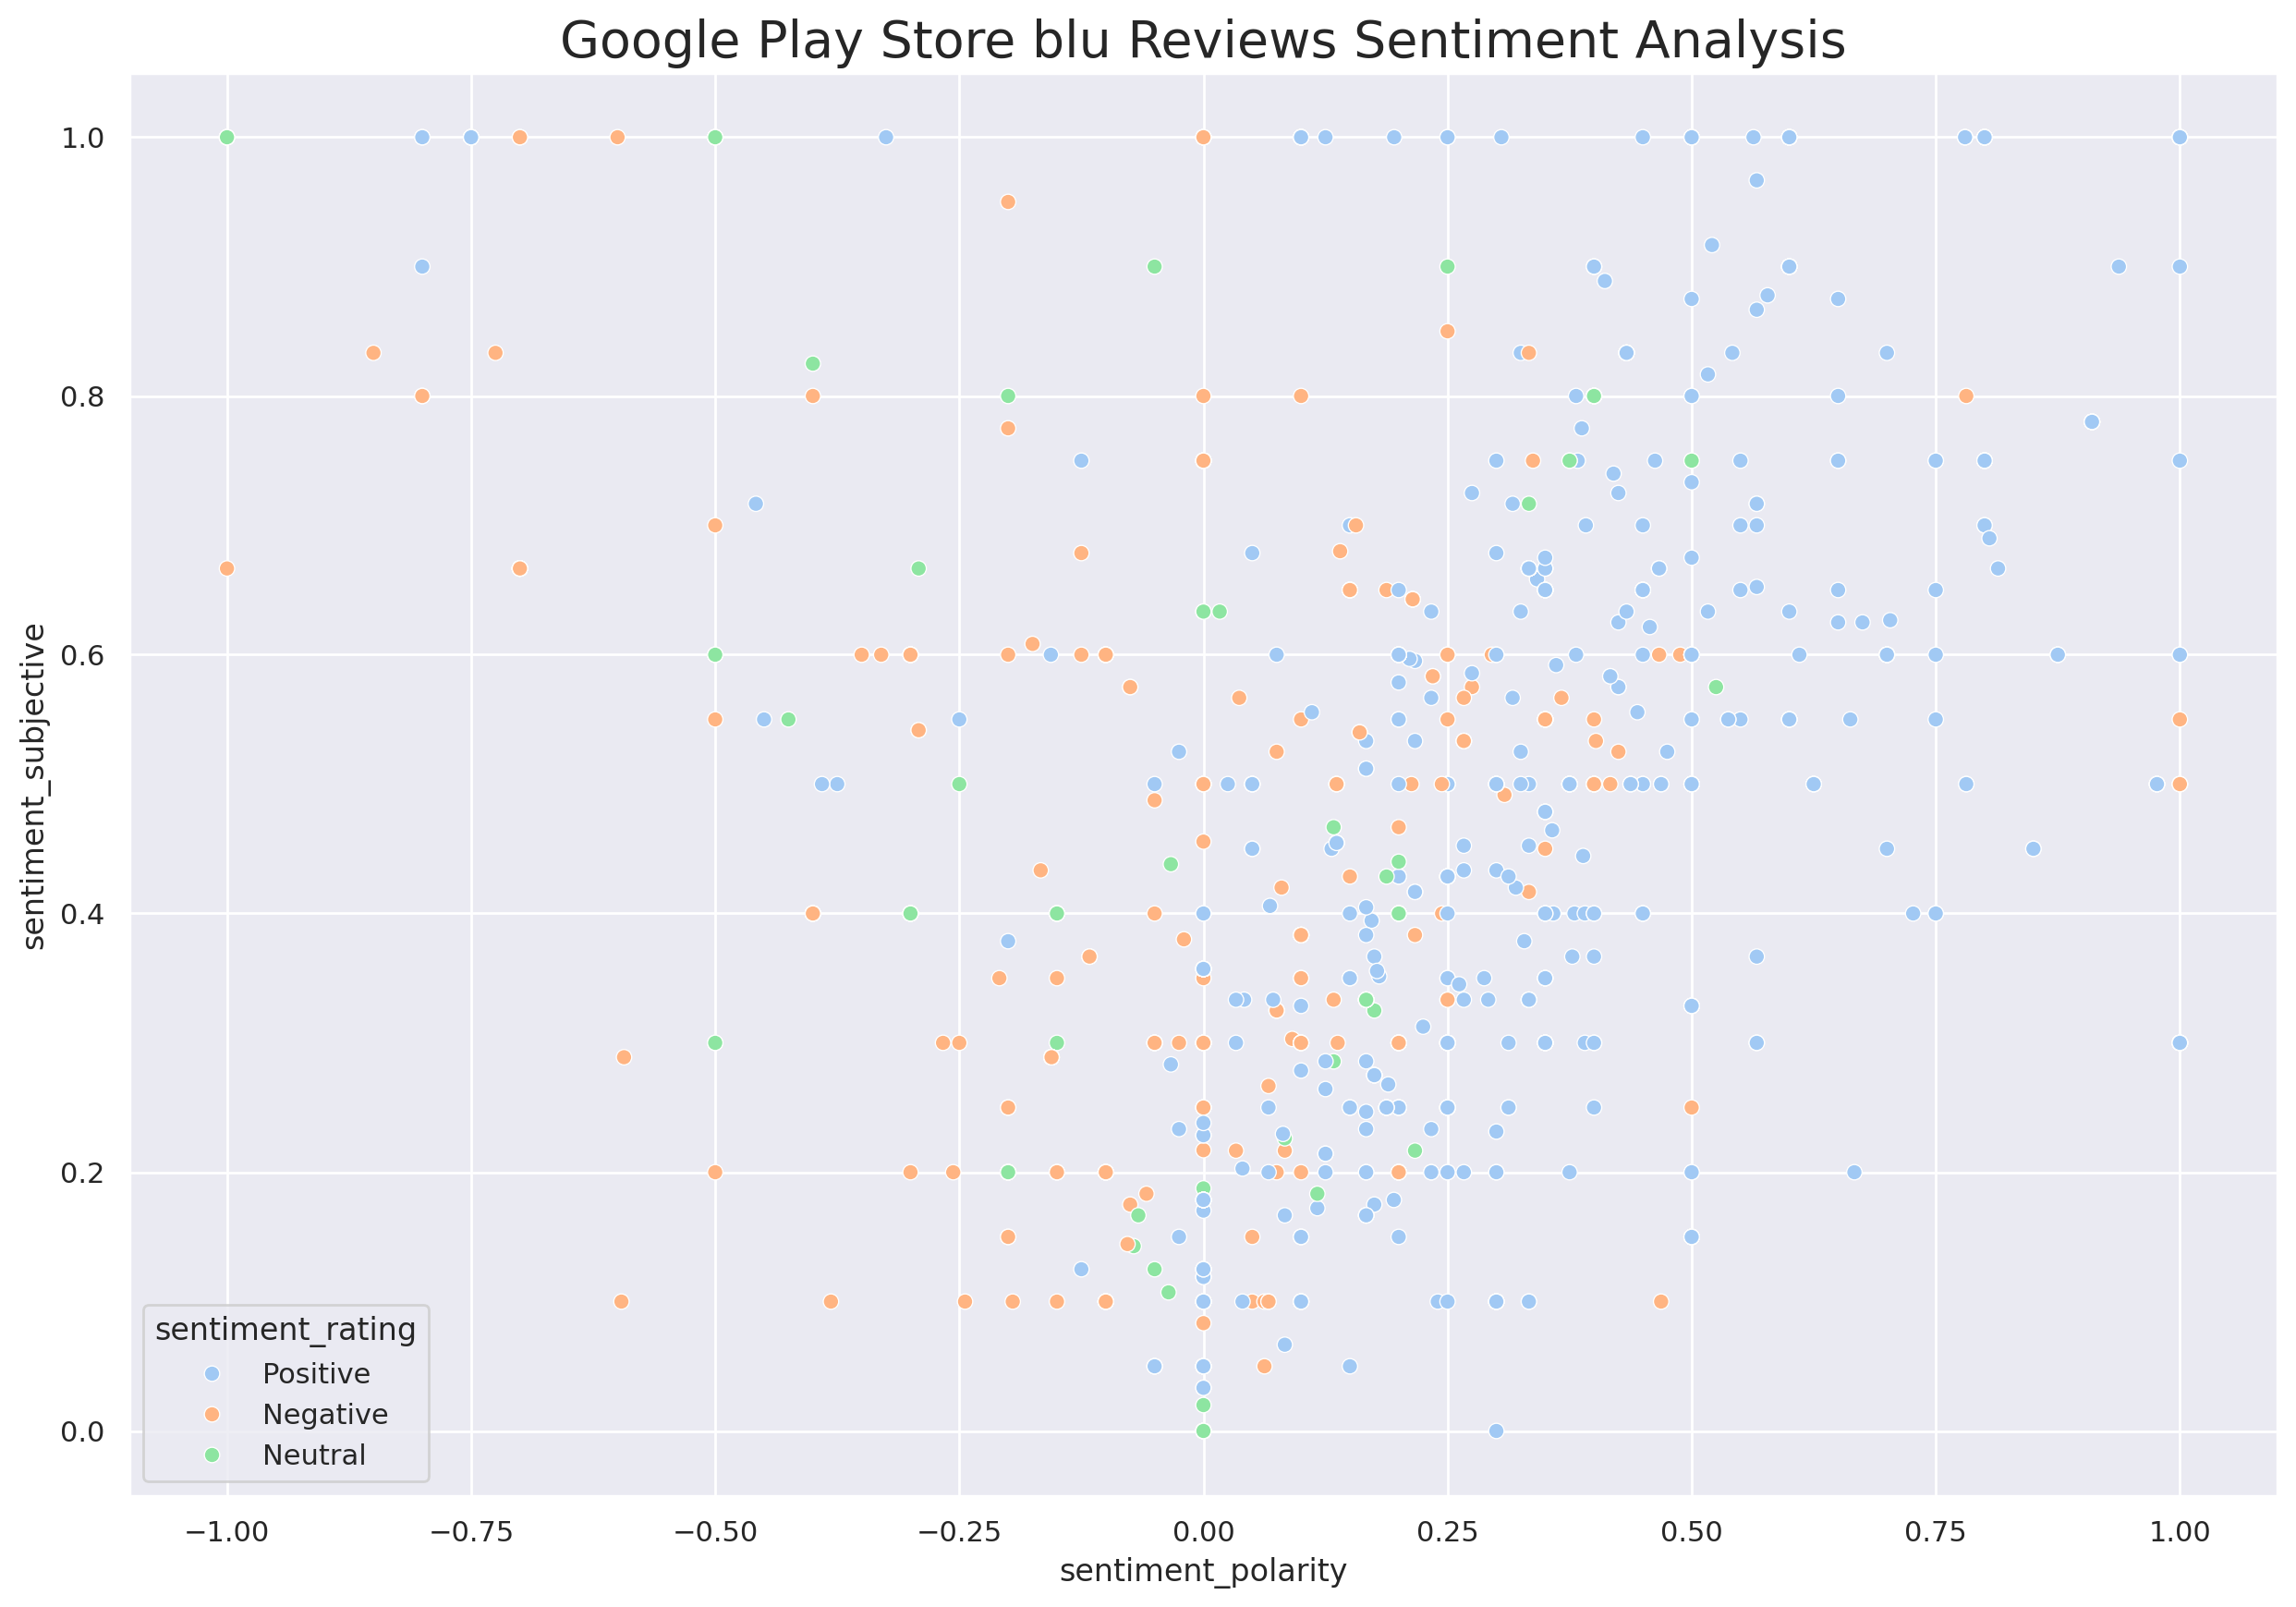

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_bluRev['sentiment_polarity'], y=df_bluRev['sentiment_subjective'],
                hue = df_bluRev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store blu Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [24]:
#Print the extracted emojis review column (content) before stopwords
df_bluRev.to_csv(r'df_bluRev_before_stopwords_sentiment_rating.csv', index = False)

In [39]:
import nltk
from nltk.corpus import stopwords

# Download Indonesian stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop = stopwords.words('english') + ["someone","still","and","would","need"]
stop.extend(stopwords.words('indonesian') + ["ga","gak","nya","aja","yg","ya"])
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [40]:
print(len(stop))

967


In [41]:
df_bluRev_stopwords = df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [42]:
# Exclude stopwords
pat = r'\b(?:{})\b'.format('|'.join(stop))
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['content'].str.replace(pat, '')
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['review_without_stopwords'].str.replace(r'\s+', ' ')
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
print(df_bluRev_stopwords)

                                                                                                                                 content  \
0                                                                                               semoga makin lancar aplikasi nya hueee 😭   
1                                                                           ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka   
2                                                                                                                           mantap mudah   
3                                                                                                                                 mantap   
4      gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali   
...                                                                                                                                  ...   
25338               

In [43]:
#Save into csv after applying stopwords
df_bluRev_stopwords.to_csv(r'df_bluRev_after_stopwords_sentiment_rating.csv', index = False)

In [44]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_bluRev_stopwords['wordCount'] = [len(review.split()) for review in df_bluRev_stopwords['content']]
df_bluRev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_bluRev_stopwords['review_without_stopwords']]

In [45]:
df_bluRev_stopwords.loc[:,["content","score","sentiment_polarity", "sentiment_rating","wordCount","review_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_polarity,sentiment_rating,wordCount,review_without_stopwords,wordCount_after_stopwords
0,semoga makin lancar aplikasi nya hueee 😭,5,0.0,Positive,7,semoga lancar aplikasi hueee 😭,5
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,0.0,Negative,13,kenap akun bca blokir banget ka,6
2,mantap mudah,5,0.0,Positive,2,mantap mudah,2
3,mantap,5,0.0,Positive,1,mantap,1
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,0.0,Neutral,20,"fitur login pengguna terdaftar, tolong aplikasinya perbaiki pengguna login",9
...,...,...,...,...,...,...,...
25338,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",5,0.0,Positive,6,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",6
25339,"ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,0.0,Negative,11,"ribet ...minta diaktifkan screen lock, dah aktif dijalankan.",8
25340,video call kok ngk berhasil,5,0.0,Positive,5,video call ngk berhasil,4
25341,pertamax....test,3,0.0,Neutral,1,pertamax....test,1


In [46]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

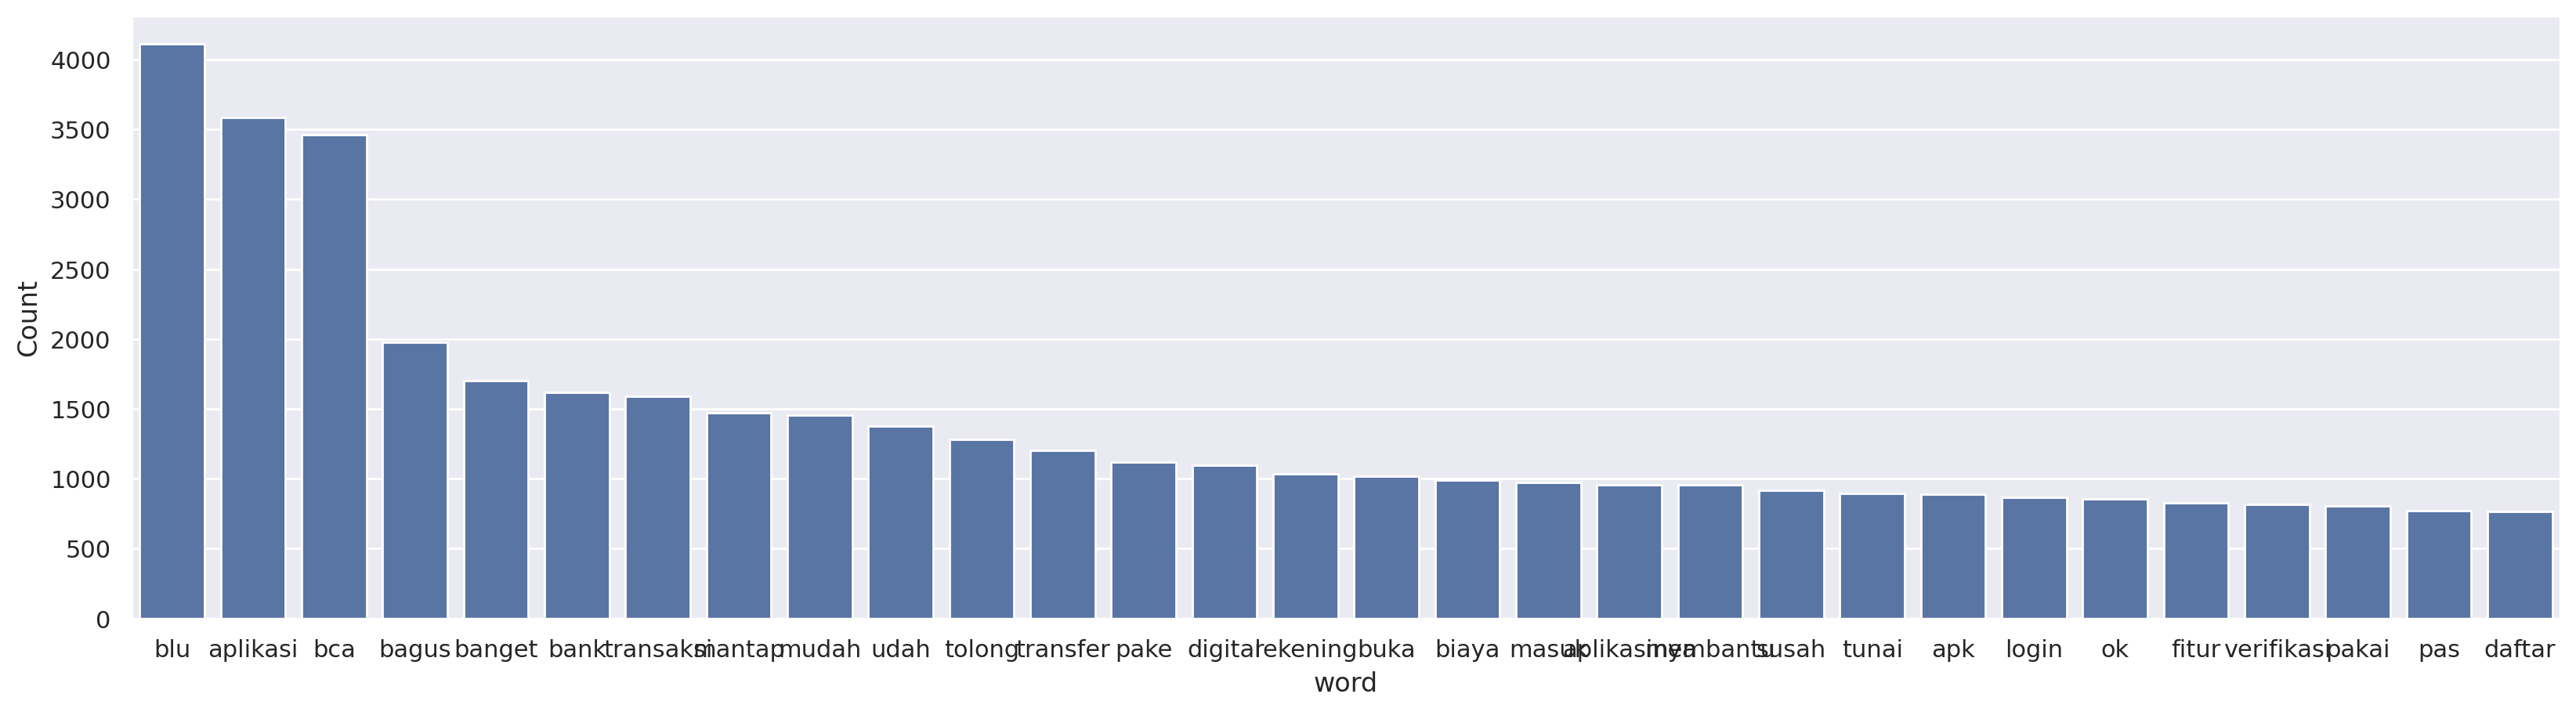

In [47]:
freq_words(df_bluRev_stopwords['review_without_stopwords'])

In [34]:
newStopWords = ["'",".",",", "someone","still","would","need"]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [35]:
#Stemming

#Stemming function chops off the end of the word
#and transform the word into its root form.
#All suffixes like -s, -es, -ed, -ing are removed.

def stemming(x):
    st = PorterStemmer()
    if x is not None:
        # Split the text, stem each word, and join them back
        return ' '.join([st.stem(word) for word in x.split()])
    return '' # Return an empty string if the input is None

df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['review_without_stopwords'].apply(lambda x:stemming(x))
print(df_bluRev_stopwords['review_without_stopwords'][9])

aplikasinya membantu manag keuangan. keren bingit 👍


In [36]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [37]:
#DROP NA
df_bluRev_stopwords.dropna(inplace=True)
df_bluRev_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25343 entries, 0 to 25342
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    25343 non-null  object 
 1   score                      25343 non-null  int64  
 2   sentiment_polarity         25343 non-null  float64
 3   sentiment_subjective       25343 non-null  float64
 4   sentiment_rating           25343 non-null  object 
 5   review_without_stopwords   25343 non-null  object 
 6   wordCount                  25343 non-null  int64  
 7   wordCount_after_stopwords  25343 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 1.5+ MB


In [38]:
df_bluRev_stopwords.loc[:,["content","score","sentiment_rating","wordCount","review_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,review_without_stopwords,wordCount_after_stopwords
0,semoga makin lancar aplikasi nya hueee 😭,5,Positive,7,semoga lancar aplikasi hueee 😭,5
1,ini kenap kok akun bca saya ke blokir tiba tiba banget ya ka,2,Negative,13,kenap akun bca blokir banget ya ka,7
2,mantap mudah,5,Positive,2,mantap mudah,2
3,mantap,5,Positive,1,mantap,1
4,"gak ada fitur login buat pengguna yang sudah terdaftar, tolong aplikasinya di perbaiki lagi agar pengguna lama bisa login kembali",3,Neutral,20,"fitur login pengguna terdaftar, tolong aplikasinya perbaiki pengguna login",9
...,...,...,...,...,...,...
25338,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",5,Positive,6,"selamat pagi masyarakat bca digital, hehehehe😁😁😁😍😍😍",6
25339,"ribet ...minta diaktifkan screen lock, dah aktif tetap ga bisa dijalankan.",1,Negative,11,"ribet ...minta diaktifkan screen lock, dah aktif dijalankan.",8
25340,video call kok ngk berhasil,5,Positive,5,video call ngk berhasil,4
25341,pertamax....test,3,Neutral,1,pertamax....test,1
